In [1]:
import pandas as pd
import tqdm
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from huggingface_hub import login

import ast

In [2]:
import re

# EDA

In [3]:
df = pd.read_csv(r'/kaggle/input/datasets/evelynuntariady/thesis/data_thesis_final.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26379 entries, 0 to 26378
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Unnamed: 0                     26379 non-null  int64 
 1   text_id                        26379 non-null  object
 2   annotators_id                  26379 non-null  object
 3   text                           26379 non-null  object
 4   topic                          26379 non-null  object
 5   is_noise_or_spam_text          26379 non-null  int64 
 6   toxicity                       26379 non-null  int64 
 7   polarized                      26379 non-null  int64 
 8   profanity_obscenity            26379 non-null  int64 
 9   threat_incitement_to_violence  26379 non-null  int64 
 10  insults                        26379 non-null  int64 
 11  identity_attack                26379 non-null  int64 
 12  sexually_explicit              26379 non-null  int64 
 13  c

In [5]:
df.head()

,Unnamed: 0,text_id,annotators_id,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text,processed_text
0,0,2026-01-01 00:00:00,"['7', '15']",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,Wajah jurnalis dibalut perban saat melaporkan ...,wajah jurnalis dibalut perban saat melaporkan ...
1,1,2026-01-10 00:00:00,"['7', '15']",Elektabilitas Paslon 02 sebentar lagi terjun b...,Disabilitas,0,0,1,0,0,0,0,0,Elektabilitas pasangan calon 02 sebentar lagi ...,elektabilitas pasangan calon sebentar lagi ter...
2,2,1-1001,"['10', '18']","Kristen, Hindu, Islam dapat perlakuan istimewa...",Kristen,0,0,1,0,0,0,0,0,"Kristen, Hindu, Islam dapat perlakuan istimewa...","kristen, hindu, islam dapat perlakuan istimewa..."
3,3,1-1004,"['10', '18']","Masyarakat Kristen, Hindu, Budha, dan etnis Ti...","Kristen, Tionghoa",0,0,0,0,0,0,0,0,"Masyarakat Kristen, Hindu, Buddha, dan etnis T...","masyarakat kristen, hindu, buddha, dan etnis t..."
4,4,1-1005,"['10', '18']",Cina Mengirimkan Satelit Penginderaan Jauh Bar...,Tionghoa,0,0,0,0,0,0,0,0,Cina mengirimkan satelit penginderaan jauh bar...,cina mengirimkan satelit penginderaan jauh bar...


In [6]:
# df['text_id'].value_counts().to_json('text_id_unique.json')

In [7]:
temp = df[df['text_id'] == '2026-02-19 00:00:00']
temp

,Unnamed: 0,text_id,annotators_id,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text,processed_text
10364,10364,2026-02-19 00:00:00,['20'],Nazi Hitler 6 Tahun Zionis ‘Israel’ 75 Tahun #...,Jewish,0,1,1,0,1,0,0,0,"Nazi Hitler 6 tahun, Zionis 'Israel' 75 tahun ...","nazi hitler tahun, zionis israel tahun freepal..."


In [8]:
# temp = raw_df[raw_df['text_id'] == '2-19']
# temp

Fix Error Text Id

In [9]:
def transform_datetime_id(text_id_str):
    # Regex to match the datetime pattern like 'YYYY-MM-DD HH:MM:SS'
    match = re.match(r'(\d+)-(\d{2})-(\d{2}) \d{2}:\d{2}:\d{2}', str(text_id_str))
    if match:
        year_part = match.group(1)
        month_part = int(match.group(2))
        day_part = int(match.group(3))

        if year_part == '2026':
            # For year 2026, format as month-day (e.g., '1-1')
            return f"{month_part}-{day_part}"
        else:
            # For other years, format as month-original_year (e.g., '2-8783')
            return f"{month_part}-{year_part}"
    else:
        return text_id_str  # Return original if pattern doesn't match

# Apply this transformation to the 'text_id' column of your DataFrame
df['text_id'] = df['text_id'].apply(transform_datetime_id)

In [10]:
# temp = df[df['text_id'] == '2-19']
# temp

In [11]:
raw_df = pd.read_csv(r'/kaggle/input/datasets/evelynuntariady/thesis/raw_data_all.csv')

In [12]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27833 entries, 0 to 27832
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   NUMBER                                   4102 non-null   object 
 1   text_id                                  27833 non-null  object 
 2   annotators_id                            27833 non-null  object 
 3   text                                     27832 non-null  object 
 4   initial_paragraph                        1642 non-null   object 
 5   topic                                    27833 non-null  object 
 6   is_noise_or_spam_text                    27833 non-null  object 
 7   related_to_election_2024                 27833 non-null  object 
 8   toxicity                                 27833 non-null  object 
 9   polarized                                27833 non-null  object 
 10  profanity_obscenity                      27833

In [13]:
raw_df.head()

,NUMBER,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,...,agreement_toxicity,agreement_polarized,agreement_profanity_obscenity,agreement_threat_incitement_to_violence,agreement_insults,agreement_identity_attack,agreement_sexually_explicit,ALL AGREE\n,CHECKPOINT,n_annotator
0,NaN,1-1,"['7', '15']",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,"['0', '0']","['0', '0']","['0', '0']","['0', '0']",...,True,True,True,True,True,True,True,True,NaN,NaN
1,NaN,1-10,"['7', '15']",Elektabilitas Paslon 02 sebentar lagi terjun b...,NaN,Disabilitas,"['0', '0']","['1', '1']","['0', '0']","['1', '1']",...,True,True,True,True,True,True,True,True,NaN,NaN
2,1,1-100,"['7', '15', '32']",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,"['0', '0', '0']","['1', '0']","['1', '0', '1']","['0', '0', '0']",...,False,True,True,True,False,True,True,False,True,3.0
3,2,1-1000,"['7', '15', '32']",Relawan Tionghoa Kalbar yg di Jakarta mendekla...,NaN,Tionghoa,"['0', '0', '0']","['1', '1']","['0', '0', '0']","['1', '0', '0']",...,True,False,True,True,True,True,True,False,True,3.0
4,NaN,1-1001,"['10', '18']","Kristen, Hindu, Islam dapat perlakuan istimewa...",NaN,Kristen,"['0', '0']","['1', '1']","['0', '0']","['1', '1']",...,True,True,True,True,True,True,True,True,NaN,NaN


## Join Raw Data With Preprocessed Text

In [14]:
raw_df['key'] = raw_df['text_id'].astype(str) + '_' + raw_df['annotators_id'].astype(str)
df['key'] = df['text_id'].astype(str) + '_' + df['annotators_id'].astype(str)

In [15]:
df_main = raw_df.merge(df[['key', 'cleaned_text', 'processed_text']], how='left', on=['key'])

In [16]:
df_main.head()

,NUMBER,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,...,agreement_threat_incitement_to_violence,agreement_insults,agreement_identity_attack,agreement_sexually_explicit,ALL AGREE\n,CHECKPOINT,n_annotator,key,cleaned_text,processed_text
0,NaN,1-1,"['7', '15']",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,"['0', '0']","['0', '0']","['0', '0']","['0', '0']",...,True,True,True,True,True,NaN,NaN,"1-1_['7', '15']",Wajah jurnalis dibalut perban saat melaporkan ...,wajah jurnalis dibalut perban saat melaporkan ...
1,NaN,1-10,"['7', '15']",Elektabilitas Paslon 02 sebentar lagi terjun b...,NaN,Disabilitas,"['0', '0']","['1', '1']","['0', '0']","['1', '1']",...,True,True,True,True,True,NaN,NaN,"1-10_['7', '15']",Elektabilitas pasangan calon 02 sebentar lagi ...,elektabilitas pasangan calon sebentar lagi ter...
2,1,1-100,"['7', '15', '32']",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,"['0', '0', '0']","['1', '0']","['1', '0', '1']","['0', '0', '0']",...,True,False,True,True,False,True,3.0,"1-100_['7', '15', '32']","Gini aja deh @KPU_ID, usul aja nih. Gimana kal...","gini saja deh , usul saja nih. gimana kalau mi..."
3,2,1-1000,"['7', '15', '32']",Relawan Tionghoa Kalbar yg di Jakarta mendekla...,NaN,Tionghoa,"['0', '0', '0']","['1', '1']","['0', '0', '0']","['1', '0', '0']",...,True,True,True,True,False,True,3.0,"1-1000_['7', '15', '32']",Relawan Tionghoa Kalbar yang di Jakarta mendek...,relawan tionghoa kalbar yang di jakarta mendek...
4,NaN,1-1001,"['10', '18']","Kristen, Hindu, Islam dapat perlakuan istimewa...",NaN,Kristen,"['0', '0']","['1', '1']","['0', '0']","['1', '1']",...,True,True,True,True,True,NaN,NaN,"1-1001_['10', '18']","Kristen, Hindu, Islam dapat perlakuan istimewa...","kristen, hindu, islam dapat perlakuan istimewa..."


In [17]:
df_main.drop(columns=['NUMBER', 'initial_paragraph', 'related_to_election_2024', 'agreement_is_noise_or_spam_text',
                      'agreement_related_to_election_2024',	'agreement_toxicity',	'agreement_polarized',	'agreement_profanity_obscenity',
                      'agreement_threat_incitement_to_violence',	'agreement_insults',	'agreement_identity_attack',	'agreement_sexually_explicit',
                      'ALL AGREE\n',	'CHECKPOINT',	'n_annotator'], inplace=True)

In [18]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27833 entries, 0 to 27832
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        27833 non-null  object
 1   annotators_id                  27833 non-null  object
 2   text                           27832 non-null  object
 3   topic                          27833 non-null  object
 4   is_noise_or_spam_text          27833 non-null  object
 5   toxicity                       27833 non-null  object
 6   polarized                      27833 non-null  object
 7   profanity_obscenity            27833 non-null  object
 8   threat_incitement_to_violence  27833 non-null  object
 9   insults                        27833 non-null  object
 10  identity_attack                27833 non-null  object
 11  sexually_explicit              27833 non-null  object
 12  key                            27833 non-null  object
 13  c

In [19]:
# df_main.to_csv('thesis_full.csv', index=False)

In [20]:
temp = df_main[df_main['cleaned_text'].isna()]
temp

,text_id,annotators_id,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,key,cleaned_text,processed_text
5,1-1002,"['10', '18']",Tweis yahudi Bleping muslim Nujins hindu Anzeg...,Jewish,"['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","1-1002_['10', '18']",NaN,NaN
36,1-1030,"['10', '18']",ANIES TUNAIKAN IBADAH HAJI Oleh: H. Agus M. Z....,UNKNOWN,"['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","1-1030_['10', '18']",NaN,NaN
118,1-1106,"['10', '18', '32']",Seandainya Kristen dan Yahudi di dunia ini tid...,"Kristen, Jewish","['1', '0', '1']","['0', '1', '0']","['0', '0', '0']","['0', '0', '0']","['0', '0', '0']","['0', '1', '0']","['0', '0', '0']","['0', '0', '0']","1-1106_['10', '18', '32']",NaN,NaN
127,1-1114,"['10', '18', '32']",Jawa + Tionghoa = Bokep,Tionghoa,"['0', '1', '1']","['0', '1', '1']","['0', '0', '0']","['0', '0', '0']","['0', '0', '0']","['0', '1', '1']","['0', '0', '1']","['0', '0', '0']","1-1114_['10', '18', '32']",NaN,NaN
150,1-1137,"['10', '18', '32']",Fansign China dimulai 📸\nCowok kalian kelihata...,Tionghoa,"['1', '0', '1']","['0', '0', '0']","['0', '0', '0']","['0', '0', '0']","['0', '0', '0']","['0', '0', '0']","['0', '0', '0']","['0', '0', '0']","1-1137_['10', '18', '32']",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27622,4-809,['19'],Pengakuan Nabi Isa dlm Al-Qur'an bahwa setelah...,Kristen,['1'],['0'],['0'],['0'],['0'],['0'],['0'],['0'],4-809_['19'],NaN,NaN
27634,4-82,['19'],: “Surya Paloh tarik Dukungannya untuk Anies d...,UNKNOWN,['1'],['0'],['0'],['0'],['0'],['0'],['0'],['0'],4-82_['19'],NaN,NaN
27652,4-836,['19'],@IATeam____ Syiah zaidiyah yg ada di yaman Uta...,Syiah,['1'],['0'],['0'],['0'],['0'],['0'],['0'],['0'],4-836_['19'],NaN,NaN
27745,4-92,['19'],Imigran Yaman lagi menasehati dirinya sendiri....,Rohingya,['1'],['0'],['0'],['0'],['0'],['0'],['0'],['0'],4-92_['19'],NaN,NaN


# Preprocess

In [21]:
cols = [
'is_noise_or_spam_text',
'toxicity',
'polarized',
'profanity_obscenity',
'threat_incitement_to_violence',
'insults',
'identity_attack',
'sexually_explicit'
]

for col in cols:
    df_main[col] = df_main[col].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) else x)

In [22]:
print(df_main['is_noise_or_spam_text'].iloc[0])
print(type(df_main['is_noise_or_spam_text'].iloc[0]))

print(df_main['polarized'].iloc[0])
print(type(df_main['polarized'].iloc[0]))

print(df_main['profanity_obscenity'].iloc[0])
print(type(df_main['profanity_obscenity'].iloc[0]))

print(df_main['insults'].iloc[0])
print(type(df_main['insults'].iloc[0]))

print(df_main['sexually_explicit'].iloc[0])
print(type(df_main['sexually_explicit'].iloc[0]))

print(df_main['identity_attack'].iloc[0])
print(type(df_main['identity_attack'].iloc[0]))

print(df_main['toxicity'].iloc[0])
print(type(df_main['toxicity'].iloc[0]))

['0', '0']
<class 'list'>
['0', '0']
<class 'list'>
['0', '0']
<class 'list'>
['0', '0']
<class 'list'>
['0', '0']
<class 'list'>
['0', '0']
<class 'list'>
['0', '0']
<class 'list'>


In [23]:
df_main.iloc[5389]

text_id                                                                     1-6084
annotators_id                                                    ['20', '5', '33']
text                             Sosialisasi dan Edukasi Pasar Modal Terpadu Ha...
topic                                                                        Syiah
is_noise_or_spam_text                                                  ([0, 1], 0)
toxicity                                                                 [0, 0, 0]
polarized                                                                [0, 0, 0]
profanity_obscenity                                                      [0, 0, 0]
threat_incitement_to_violence                                            [0, 0, 0]
insults                                                                  [0, 0, 0]
identity_attack                                                          [0, 0, 0]
sexually_explicit                                                        [0, 0, 0]
key 

In [24]:
df_main['is_noise_or_spam_text'].iloc[5389] = [0, 1, 0]

/tmp/ipykernel_58/1462503684.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_main['is_noise_or_spam_text'].iloc[5389] = [0, 1, 0]


In [25]:
for col in cols:
    for idx, x in df_main[col].items():
        try:
            for i in x:
                int(i)
        except Exception as e:
            print(f"Column: {col}")
            print(f"Row: {idx}")
            print("Cell:", x)
            print("Cell type:", type(x))
            print("Element types:", [type(i) for i in x])
            raise

In [26]:
def majority_vote(x):
    x = [int(i) for i in x]
    return round(sum(x)/len(x))

for col in cols:
    df_main[col] = df_main[col].apply(majority_vote)

In [27]:
df_main.head(1)

,text_id,annotators_id,text,topic,is_noise_or_spam_text,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,key,cleaned_text,processed_text
0,1-1,"['7', '15']",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,UNKNOWN,0,0,0,0,0,0,0,0,"1-1_['7', '15']",Wajah jurnalis dibalut perban saat melaporkan ...,wajah jurnalis dibalut perban saat melaporkan ...


Drop noise text

In [28]:
df_main = df_main[df_main['is_noise_or_spam_text'] == 0]

In [29]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26380 entries, 0 to 27832
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        26380 non-null  object
 1   annotators_id                  26380 non-null  object
 2   text                           26379 non-null  object
 3   topic                          26380 non-null  object
 4   is_noise_or_spam_text          26380 non-null  int64 
 5   toxicity                       26380 non-null  int64 
 6   polarized                      26380 non-null  int64 
 7   profanity_obscenity            26380 non-null  int64 
 8   threat_incitement_to_violence  26380 non-null  int64 
 9   insults                        26380 non-null  int64 
 10  identity_attack                26380 non-null  int64 
 11  sexually_explicit              26380 non-null  int64 
 12  key                            26380 non-null  object
 13  cleane

In [30]:
df_main = df_main.dropna()

In [31]:
df_main.isnull().sum()

text_id                          0
annotators_id                    0
text                             0
topic                            0
is_noise_or_spam_text            0
toxicity                         0
polarized                        0
profanity_obscenity              0
threat_incitement_to_violence    0
insults                          0
identity_attack                  0
sexually_explicit                0
key                              0
cleaned_text                     0
processed_text                   0
dtype: int64

In [32]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26375 entries, 0 to 27832
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        26375 non-null  object
 1   annotators_id                  26375 non-null  object
 2   text                           26375 non-null  object
 3   topic                          26375 non-null  object
 4   is_noise_or_spam_text          26375 non-null  int64 
 5   toxicity                       26375 non-null  int64 
 6   polarized                      26375 non-null  int64 
 7   profanity_obscenity            26375 non-null  int64 
 8   threat_incitement_to_violence  26375 non-null  int64 
 9   insults                        26375 non-null  int64 
 10  identity_attack                26375 non-null  int64 
 11  sexually_explicit              26375 non-null  int64 
 12  key                            26375 non-null  object
 13  cleane

In [33]:
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "yg": "yang",
    "lu": "kamu",
    "loe": "kamu",
    "gw": "saya",
    "gue": "saya",
    "bgt": "banget",
    "dgn": "dengan",
    "krn": "karena",
    "aja": "saja",
    "trs": "terus"
}

In [34]:
import re

def normalize_slang(text, slang_dict):
    words = text.split()
    return " ".join([slang_dict.get(w.lower(), w) for w in words])

def preprocess_text(text, slang_dict, lowercase=True):
    if not isinstance(text, str):
        return ""

    # 1. remove username (@user)
    text = re.sub(r'@\w+', '', text)

    # 2. remove URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. remove unwanted symbols (keep .,!?)
    text = re.sub(r'[^\w\s.,!?]', '', text)

    # 5. normalize slang
    text = normalize_slang(text, slang_dict)

    # 6. normalize repeated chars (contoh: anjiiing → anjiing)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. lowercase (optional)
    if lowercase:
        text = text.lower()

    # 8. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [35]:
from tqdm import tqdm
tqdm.pandas()

df_main["processed_text"] = (
    df_main["cleaned_text"]
    .fillna("")
    .astype(str)
    .progress_apply(
        lambda x: preprocess_text(x, slang_dict)
    )
)

100%|██████████| 26375/26375 [00:01<00:00, 18030.65it/s]


# Modeling

In [36]:
df_main['toxicity'].value_counts()

toxicity
0    23976
1     2399
Name: count, dtype: int64

## Split Data

In [38]:
x = df_main['processed_text']
y = df_main['toxicity']

In [39]:
x_train, X_test, y_train, Y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

In [40]:
x_val, x_test, y_val, y_test = train_test_split(X_test, Y_test, test_size=0.2, stratify = Y_test, random_state=42)

In [41]:
train_df = pd.DataFrame({"processed_text": x_train, "label": y_train})
test_df = pd.DataFrame({"processed_text": x_test, "label": y_test})
val_df = pd.DataFrame({"processed_text": x_val, "label": y_val})

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df),
    "val": Dataset.from_pandas(val_df)
})


In [42]:
print(dataset['train'].column_names)

['processed_text', 'label', '__index_level_0__']


## FIneTune

### Stage 1 (Binary Classification)

In [ ]:
from transformers import AutoTokenizer, Trainer, TrainingArguments, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["processed_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [ ]:
tokenized_datasets_1 = dataset.map(tokenize, batched=True)

tokenized_datasets_1 = tokenized_datasets_1.remove_columns(["processed_text"])
tokenized_datasets_1 = tokenized_datasets_1.rename_column("label", "labels")
tokenized_datasets_1.set_format("torch")

train_dataset_1 = tokenized_datasets_1["train"]
test_dataset_1 = tokenized_datasets_1["test"]
val_dataset_1 = tokenized_datasets_1["val"]

In [ ]:
print(train_dataset_1)

In [ ]:
from transformers import AutoModelForSequenceClassification

def model_init_s1():
    return AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL,
        num_labels=2
    )

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, auc, roc_curve
def compute_metrics_s1(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "recall": recall_score(labels, preds),
        "precision": precision_score(labels, preds),
        "roc_auc": auc(roc_curve(labels, preds)[0], roc_curve(labels, preds)[1])
    }

In [ ]:
BASE_MODEL = "indolem/indobertweet-base-uncased"

In [59]:
from transformers import (
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

In [ ]:
from transformers import Trainer, TrainingArguments
import gc
import torch


def run_experiment_s1(
    experiment_name,
    learning_rate=1e-5,
    batch_size=8,
    num_epochs=5,
    weight_decay=0.0,
    warmup_ratio=0.0
):

    output_dir = f"./finetuning_s1/{experiment_name}"

    args = TrainingArguments(
        output_dir=output_dir,

        # Training
        num_train_epochs=num_epochs,
        learning_rate=learning_rate,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,

        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,

        # Evaluation
        eval_strategy="epoch",
        save_strategy="epoch",

        load_best_model_at_end=True,

        metric_for_best_model="f1",
        greater_is_better=True,

        # Logging
        logging_steps=50,

        # Reproducibility
        seed=42,
        data_seed=42,

        # Other
        save_only_model = True,
        save_total_limit = 2,
        remove_unused_columns=False,
        report_to="none"
    )

    trainer = Trainer(
        model=model_init_s1(),
        args=args,

        train_dataset=train_dataset_1,
        eval_dataset=val_dataset_1,

        # tokenizer=tokenizer,
        compute_metrics=compute_metrics_s1,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    trainer.train()
    print(args.save_only_model)
    metrics = trainer.evaluate()
    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

In [57]:
search_space = [
    {
        "learning_rate": 1e-5,
        "batch_size": 8,
        "num_epochs": 5,
        "weight_decay": 0.0,
        "warmup_ratio": 0.0
    },
    {
        "learning_rate": 2e-5,
        "batch_size": 8,
        "num_epochs": 5,
        "weight_decay": 0.0,
        "warmup_ratio": 0.0
    },
    {
        "learning_rate": 3e-5,
        "batch_size": 8,
        "num_epochs": 5,
        "weight_decay": 0.0,
        "warmup_ratio": 0.0
    },

    {
        "learning_rate": 2e-5,
        "batch_size": 16,
        "num_epochs": 5,
        "weight_decay": 0.0,
        "warmup_ratio": 0.0
    },

    {
        "learning_rate": 2e-5,
        "batch_size": 16,
        "num_epochs": 3,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1
    },

    {
        "learning_rate": 2e-5,
        "batch_size": 16,
        "num_epochs": 5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1
    },

    {
        "learning_rate": 3e-5,
        "batch_size": 16,
        "num_epochs": 5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1
    }
]

In [ ]:
results = []

for i, config in enumerate(search_space):

    print(f"\n===== EXPERIMENT {i+1}/{len(search_space)} =====")
    print(config)

    metrics = run_experiment_s1(
        experiment_name=f"exp_{i+1}",
        **config
    )

    results.append({
        **config,
        **metrics
    })

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "eval_f1",
    ascending=False
)

results_df

In [ ]:
best_config = results_df.iloc[0]

print("BEST CONFIGURATION")
print(best_config)

In [ ]:
def train_final_s1(
    learning_rate,
    batch_size,
    num_epochs,
    weight_decay,
    warmup_ratio
):

    args = TrainingArguments(
        output_dir="./final_s1",

        num_train_epochs=num_epochs,
        learning_rate=learning_rate,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,

        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,

        eval_strategy="epoch",
        save_strategy="epoch",

        load_best_model_at_end=True,

        metric_for_best_model="f1",
        greater_is_better=True,

        logging_steps=50,

        seed=42,
        data_seed=42,

        remove_unused_columns=False,
        report_to="none",

        save_only_model=True,
        save_total_limit=2
    )

    final_trainer = Trainer(
        model=model_init_s1(),
        args=args,

        train_dataset=train_dataset_1,
        eval_dataset=val_dataset_1,

        # tokenizer=tokenizer,
        compute_metrics=compute_metrics_s1,

        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    final_trainer.train()

    final_metrics = final_trainer.evaluate()

    return final_trainer, final_metrics

In [ ]:
final_trainer, final_metrics = train_final_s1(
    learning_rate=float(best_config["learning_rate"]),
    batch_size=int(best_config["batch_size"]),
    num_epochs=int(best_config["num_epochs"]),
    weight_decay=float(best_config["weight_decay"]),
    warmup_ratio=float(best_config["warmup_ratio"])
)

In [ ]:
history = final_trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs = [x['epoch'] for x in history if 'eval_loss' in x]

In [ ]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(range(0, len(train_loss), len(train_loss)//len(val_loss)), val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
evaluation_results1 = final_trainer.evaluate()
print(evaluation_results1)

In [ ]:
pred1 = final_trainer.predict(test_dataset_1)
pred_label1 = pred1.predictions.argmax(axis=1)

y_test_numeric = y_test

print(classification_report(y_test_numeric, pred_label1))

In [ ]:
from huggingface_hub import login

login()

In [ ]:
final_trainer.save_model("./final_s1")
tokenizer.save_pretrained("./final_s1")

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

api.create_repo(
    repo_id="evelnap/hatespeech-finetuned-stage1",
    repo_type="model",
    exist_ok=True
)

api.upload_folder(
    folder_path="./finetuning_s1",
    repo_id="evelnap/hatespeech-finetuned-stage1",
    repo_type="model"
)

### Stage 2

In [43]:
df_toxic = df_main[df_main["toxicity"] == 1].copy()

In [44]:
LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

X = df_toxic["processed_text"]
y2 = df_toxic[LABEL_COLS]

In [45]:
df_toxic[LABEL_COLS] = df_toxic[LABEL_COLS].astype("float32")

In [ ]:
from sklearn.model_selection import train_test_split

train_df_s2, test1_df_s2 = train_test_split(
    df_toxic,
    test_size=0.2,
    random_state=42
)
val_df_s2, test_df_s2 = train_test_split(test1_df_s2, test_size = 0.2, random_state = 42)

train_df_s2 = train_df_s2[["processed_text"] + LABEL_COLS].copy()
test_df_s2 = test_df_s2[["processed_text"] + LABEL_COLS].copy()
val_df_s2 = val_df_s2[["processed_text"] + LABEL_COLS].copy()

# train_df_s2["label"] = train_df_s2[LABEL_COLS].values.tolist()
# test_df_s2["label"] = test_df_s2[LABEL_COLS].values.tolist()

train_df_s2["label"] = train_df_s2[LABEL_COLS].astype(float).values.tolist()
test_df_s2["label"] = test_df_s2[LABEL_COLS].astype(float).values.tolist()
val_df_s2["label"] = val_df_s2[LABEL_COLS].astype(float).values.tolist()

train_df_s2 = train_df_s2[["processed_text", "label"]]
test_df_s2 = test_df_s2[["processed_text", "label"]]
val_df_s2 = val_df_s2[["processed_text", "label"]]

In [ ]:
from datasets import Dataset

dataset_s2 = DatasetDict({
    "train": Dataset.from_pandas(train_df_s2.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df_s2.reset_index(drop=True)),
    "val": Dataset.from_pandas(val_df_s2.reset_index(drop=True))
})

In [48]:
from transformers import AutoTokenizer

tokenizer_s2 = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [49]:
def tokenize_s2(batch):
    return tokenizer_s2(
        batch["processed_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_datasets_2 = dataset_s2.map(
    tokenize_s2,
    batched=True
)

tokenized_datasets_2 = tokenized_datasets_2.remove_columns(
    ["processed_text"]
)

tokenized_datasets_2 = tokenized_datasets_2.rename_column(
    "label",
    "labels"
)

tokenized_datasets_2.set_format("torch")
train_dataset_2 = tokenized_datasets_2["train"]
test_dataset_2 = tokenized_datasets_2["test"]
val_dataset_2 = tokenized_datasets_2["val"]


Map:   0%|          | 0/1919 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

Map:   0%|          | 0/384 [00:00<?, ? examples/s]

In [50]:
print(tokenized_datasets_2["train"][0]["labels"])

tensor([1., 0., 0., 0., 0.])


In [52]:
from transformers import AutoModelForSequenceClassification

BASE_MODEL = "indolem/indobertweet-base-uncased"

def model_init_s2():

    model = AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL,
        num_labels=len(LABEL_COLS),
        problem_type="multi_label_classification"
    )

    return model

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score,precision_score, recall_score


def compute_metrics_s2(eval_pred):
    logits, labels = eval_pred



    preds = (logits > 0).astype(int)

    return {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "accuracy": accuracy_score(labels, preds),
        "recall_micro": recall_score(
            labels,
            preds,
            average="micro",
            zero_division=0
        ),

        "precision_micro": precision_score(
            labels,
            preds,
            average="micro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            labels,
            preds,
            average="macro",
            zero_division=0
        ),

        "precision_macro": precision_score(
            labels,
            preds,
            average="macro",
            zero_division=0
        )

    }

In [62]:
from transformers import Trainer, TrainingArguments
import gc
import torch


def run_experiment_s2(
    experiment_name,
    learning_rate=1e-5,
    batch_size=8,
    num_epochs=5,
    weight_decay=0.0,
    warmup_ratio=0.0
):

    output_dir = f"./finetuning_s2/{experiment_name}"

    args = TrainingArguments(
        output_dir=output_dir,

        # Training
        num_train_epochs=num_epochs,
        learning_rate=learning_rate,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,

        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,

        # Evaluation
        eval_strategy="epoch",
        save_strategy="epoch",

        load_best_model_at_end=True,

        metric_for_best_model="f1_macro",
        greater_is_better=True,

        # Logging
        logging_steps=50,

        # Reproducibility
        seed=42,
        data_seed=42,

        # Other
        save_only_model = True,
        save_total_limit = 2,
        remove_unused_columns=False,
        report_to="none"
    )

    trainer = Trainer(
        model=model_init_s2(),
        args=args,

        train_dataset=train_dataset_2,
        eval_dataset=val_dataset_2,

        # tokenizer=tokenizer,
        compute_metrics=compute_metrics_s2,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    trainer.train()
    print(args.save_only_model)
    metrics = trainer.evaluate()
    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

In [63]:
results_s2 = []

for i, config in enumerate(search_space):

    print(f"\n===== EXPERIMENT {i+1}/{len(search_space)} =====")
    print(config)

    metrics_s2 = run_experiment_s2(
        experiment_name=f"exp_{i+1}",
        **config
    )

    results_s2.append({
        **config,
        **metrics_s2
    })

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



===== EXPERIMENT 1/7 =====
{'learning_rate': 1e-05, 'batch_size': 8, 'num_epochs': 5, 'weight_decay': 0.0, 'warmup_ratio': 0.0}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Weighted,Accuracy,Recall Micro,Precision Micro,Recall Macro,Precision Macro
1,0.809106,0.778285,0.343693,0.160705,0.321303,0.273438,0.233251,0.652778,0.116588,0.259241
2,0.773272,0.733435,0.474320,0.266071,0.453126,0.335938,0.389578,0.606178,0.220644,0.376201
3,0.695017,0.710639,0.542185,0.325530,0.522140,0.359375,0.486352,0.612500,0.294074,0.378152
4,0.678378,0.706629,0.567320,0.411632,0.553046,0.361979,0.538462,0.599448,0.369582,0.554577
5,0.637523,0.704992,0.567674,0.411707,0.553609,0.369792,0.535980,0.603352,0.367950,0.556104


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

True


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [67]:
results_df_s2 = pd.DataFrame(results_s2)

results_df_s2 = results_df_2.sort_values(
    "eval_f1_macro",
    ascending=False
)

results_df_s2

,learning_rate,batch_size,num_epochs,weight_decay,warmup_ratio,eval_loss,eval_f1_micro,eval_f1_macro,eval_f1_weighted,eval_accuracy,eval_recall_micro,eval_precision_micro,eval_recall_macro,eval_precision_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
1,0.00002,8,5,0.00,0.0,0.707774,0.587202,0.469081,0.575943,0.375000,0.580645,0.593909,0.440914,0.552350,2.2028,174.325,10.895,5.0
2,0.00003,8,5,0.00,0.0,0.732601,0.579345,0.464008,0.566680,0.364583,0.570720,0.588235,0.434983,0.548692,2.2135,173.478,10.842,5.0
6,0.00003,16,5,0.01,0.1,0.717227,0.569270,0.459372,0.557109,0.354167,0.560794,0.578005,0.431874,0.544556,1.8736,204.955,6.405,5.0
3,0.00002,16,5,0.00,0.0,0.705970,0.565941,0.432853,0.553924,0.354167,0.548387,0.584656,0.395907,0.544426,1.8714,205.195,6.412,5.0
5,0.00002,16,5,0.01,0.1,0.704246,0.574026,0.427985,0.561008,0.372396,0.548387,0.602180,0.391808,0.561374,1.8660,205.789,6.431,5.0
0,0.00001,8,5,0.00,0.0,0.704992,0.567674,0.411707,0.553609,0.369792,0.535980,0.603352,0.367950,0.556104,2.2251,172.580,10.786,5.0
4,0.00002,16,3,0.01,0.1,0.730334,0.481089,0.270048,0.458513,0.341146,0.394541,0.616279,0.223395,0.400503,1.8589,206.576,6.455,3.0


In [68]:
best_config_s2 = results_df_s2.iloc[0]

print("BEST CONFIGURATION")
print(best_config_s2)

BEST CONFIGURATION
learning_rate                0.000020
batch_size                   8.000000
num_epochs                   5.000000
weight_decay                 0.000000
warmup_ratio                 0.000000
eval_loss                    0.707774
eval_f1_micro                0.587202
eval_f1_macro                0.469081
eval_f1_weighted             0.575943
eval_accuracy                0.375000
eval_recall_micro            0.580645
eval_precision_micro         0.593909
eval_recall_macro            0.440914
eval_precision_macro         0.552350
eval_runtime                 2.202800
eval_samples_per_second    174.325000
eval_steps_per_second       10.895000
epoch                        5.000000
Name: 1, dtype: float64


In [71]:
def train_final_s2(
    learning_rate,
    batch_size,
    num_epochs,
    weight_decay,
    warmup_ratio
):

    args = TrainingArguments(
        output_dir="./final_s2",

        num_train_epochs=num_epochs,
        learning_rate=learning_rate,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,

        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,

        eval_strategy="epoch",
        save_strategy="epoch",

        load_best_model_at_end=True,

        metric_for_best_model="f1_macro",
        greater_is_better=True,

        logging_steps=50,

        seed=42,
        data_seed=42,

        remove_unused_columns=False,
        report_to="none",

        save_only_model=True,
        save_total_limit=2
    )

    final_trainer = Trainer(
        model=model_init_s2(),
        args=args,

        train_dataset=train_dataset_2,
        eval_dataset=val_dataset_2,

        # tokenizer=tokenizer,
        compute_metrics=compute_metrics_s2,

        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    final_trainer.train()

    final_metrics = final_trainer.evaluate()

    return final_trainer, final_metrics

In [72]:
final_trainer_s2, final_metrics_s2 = train_final_s2(
    learning_rate=float(best_config_s2["learning_rate"]),
    batch_size=int(best_config_s2["batch_size"]),
    num_epochs=int(best_config_s2["num_epochs"]),
    weight_decay=float(best_config_s2["weight_decay"]),
    warmup_ratio=float(best_config_s2["warmup_ratio"])
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Weighted,Accuracy,Recall Micro,Precision Micro,Recall Macro,Precision Macro
1,0.778598,0.737127,0.501441,0.260100,0.466894,0.343750,0.431762,0.597938,0.232755,0.376526
2,0.709678,0.708456,0.547945,0.449012,0.535158,0.372396,0.496278,0.611621,0.399884,0.559415
3,0.596926,0.707625,0.595691,0.491437,0.585042,0.393229,0.583127,0.608808,0.458541,0.564115
4,0.551590,0.721956,0.579674,0.481066,0.569302,0.375000,0.573201,0.586294,0.449237,0.554252
5,0.494174,0.726609,0.577267,0.479931,0.567288,0.375000,0.560794,0.594737,0.442700,0.557528


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [ ]:
# from transformers import TrainingArguments, Trainer

# # for param in model_s2.base_model.parameters():
# #     param.requires_grad = False

# args_s2 = TrainingArguments(
#     output_dir="./baseline_s2",
#     num_train_epochs=5,
#     logging_steps=1,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     learning_rate = 1e-5,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True
# )

# trainer_s2 = Trainer(
#     model=model_s2,
#     args=args_s2,
#     train_dataset=train_dataset_2,
#     eval_dataset=test_dataset_2,
#     compute_metrics=compute_metrics_s2
# )


In [ ]:
# trainer_s2.train()

In [73]:
history_s2 = final_trainer_s2.state.log_history
train_loss_s2 = [x['loss'] for x in history_s2 if 'loss' in x]
val_loss_s2 = [x['eval_loss'] for x in history_s2 if 'eval_loss' in x]
epochs_s2 = [x['epoch'] for x in history_s2 if 'eval_loss' in x]

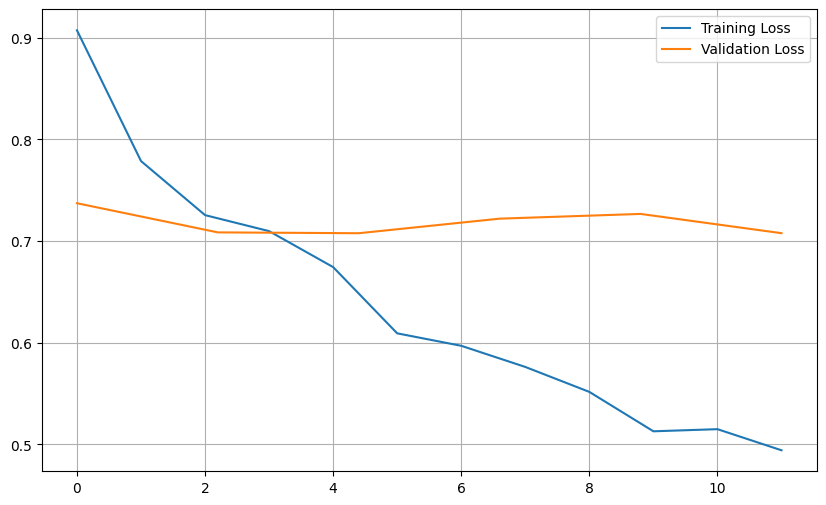

In [75]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(train_loss_s2, label='Training Loss')

plt.plot(
    np.linspace(0, len(train_loss_s2)-1, len(val_loss_s2)),
    val_loss_s2,
    label='Validation Loss'
)

plt.legend()
plt.grid(True)
plt.show()

In [76]:
evaluation_results2 = final_trainer_s2.evaluate()
print(evaluation_results2)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.7076625823974609, 'eval_f1_micro': 0.5956907477820025, 'eval_f1_macro': 0.49143717647680135, 'eval_f1_weighted': 0.5850424369421954, 'eval_accuracy': 0.3932291666666667, 'eval_recall_micro': 0.5831265508684863, 'eval_precision_micro': 0.6088082901554405, 'eval_recall_macro': 0.45854079676854653, 'eval_precision_macro': 0.5641152209917839, 'eval_runtime': 2.3112, 'eval_samples_per_second': 166.146, 'eval_steps_per_second': 10.384, 'epoch': 5.0}


In [77]:
pred2 = final_trainer_s2.predict(test_dataset_2)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [78]:
import numpy as np

logits = pred2.predictions

probs = 1 / (1 + np.exp(-logits))

threshold = 0.5
pred_label2 = (probs > threshold).astype(int)

y_true = pred2.label_ids
from sklearn.metrics import classification_report

print(classification_report(y_true, pred_label2, target_names=LABEL_COLS))

                               precision    recall  f1-score   support

                      insults       0.58      0.69      0.63        36
              identity_attack       0.56      0.59      0.57        39
threat_incitement_to_violence       0.00      0.00      0.00         6
          profanity_obscenity       0.62      0.33      0.43        15
            sexually_explicit       0.00      0.00      0.00         4

                    micro avg       0.58      0.53      0.55       100
                    macro avg       0.35      0.32      0.33       100
                 weighted avg       0.52      0.53      0.52       100
                  samples avg       0.51      0.47      0.47       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.metrics import classification_report

for i, label_name in enumerate(LABEL_COLS):

    print(f"\n===== {label_name} =====")

    print(
        classification_report(
            y_true[:, i],
            pred_label2[:, i]
        )
    )
     


===== insults =====
              precision    recall  f1-score   support

         0.0       0.79      0.70      0.74        60
         1.0       0.58      0.69      0.63        36

    accuracy                           0.70        96
   macro avg       0.69      0.70      0.69        96
weighted avg       0.71      0.70      0.70        96


===== identity_attack =====
              precision    recall  f1-score   support

         0.0       0.71      0.68      0.70        57
         1.0       0.56      0.59      0.57        39

    accuracy                           0.65        96
   macro avg       0.64      0.64      0.64        96
weighted avg       0.65      0.65      0.65        96


===== threat_incitement_to_violence =====
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97        90
         1.0       0.00      0.00      0.00         6

    accuracy                           0.94        96
   macro avg       0.47      0.50  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [80]:
from huggingface_hub import login

login()

In [81]:
final_trainer_s2.save_model("./final_s2")
tokenizer_s2.save_pretrained("./final_s2")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_s2/tokenizer_config.json', './final_s2/tokenizer.json')

In [82]:
from huggingface_hub import HfApi

api = HfApi()

api.create_repo(
    repo_id="evelnap/hatespeech-finetuned-stage2",
    repo_type="model",
    exist_ok=True
)

api.upload_folder(
    folder_path="./finetuning_s2",
    repo_id="evelnap/hatespeech-finetuned-stage2",
    repo_type="model"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/evelnap/hatespeech-finetuned-stage2/commit/ed427ee6730bc7797dc549a4ed6396dce85ff0e6', commit_message='Upload folder using huggingface_hub', commit_description='', oid='ed427ee6730bc7797dc549a4ed6396dce85ff0e6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/evelnap/hatespeech-finetuned-stage2', endpoint='https://huggingface.co', repo_type='model', repo_id='evelnap/hatespeech-finetuned-stage2'), pr_revision=None, pr_num=None)